In [ ]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║       BCNN Edge Vision Accelerator — Phase A: Data Preparation              ║
║       Target: Cyclone IV EP4CE115F29C7 via Quartus II 13.0                  ║
╚══════════════════════════════════════════════════════════════════════════════╝

Notebook structure
──────────────────
  Step 1  │ Task definition & synthetic dataset init
  Step 2  │ Float32 baseline CNN (Keras) — train & evaluate
  Step 3  │ Weight binarization via sign function
  Step 4  │ BatchNorm folding → integer thresholds
  Step 5  │ .mif file generation (Quartus ROMs)
  Step 6  │ Test-image → hex conversion  ($readmemh testbench)
  Step 7  │ Software-binarized model accuracy (RTL golden reference)

All outputs are written to ./output/ relative to this notebook.
"""

## Environment Setup

In [ ]:
import os, sys, json, struct, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam

# Sklearn helpers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)

print(f"Python      : {sys.version.split()[0]}")
print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─────────────────────────────────────────────────────────────────────────────
# Project-wide constants — change ONE place, everything updates downstream
# ─────────────────────────────────────────────────────────────────────────────
IMG_H        = 32          # image height (pixels)
IMG_W        = 32          # image width  (pixels)
IMG_C        = 1           # grayscale
NUM_CLASSES  = 2           # good=0, defective=1
CONV1_FILTERS = 8
CONV2_FILTERS = 16
KERNEL_SIZE  = 3
INPUT_BIN_THRESHOLD = 128  # pixel binarization threshold for RTL input stage
BATCH_SIZE   = 64
EPOCHS       = 30

OUTPUT_DIR   = Path("output")
MEM_DIR      = OUTPUT_DIR / "mem"
HEX_DIR      = OUTPUT_DIR / "hex"
MODEL_DIR    = OUTPUT_DIR / "models"
PLOT_DIR     = OUTPUT_DIR / "plots"

for d in [OUTPUT_DIR, MEM_DIR, HEX_DIR, MODEL_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"\nAll outputs  → {OUTPUT_DIR.resolve()}")


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Define Task & Generate Synthetic Dataset
# ═══════════════════════════════════════════════════════════════════════════════

In [ ]:
# ─────────────────────────────────────────────────────────────
# FIX 5 — Fixed-point specification (SINGLE SOURCE OF TRUTH)
# ─────────────────────────────────────────────────────────────

FIXED_POINT_SPEC = {
    "format": "Q8.8",
    "scale": 256,
    "rounding": "nearest",
    "clipping": [-32768, 32767],
    "type": "int16"
}

with open(OUTPUT_DIR / "fixed_point_spec.json", "w") as f:
    json.dump(FIXED_POINT_SPEC, f, indent=2)

print("Fixed-point spec saved → fixed_point_spec.json")

### Step 1 — Dataset: Rock Paper Scissors

 **Task**: Binary classification — Rock (class 0) vs Not-Rock / Paper+Scissors (class 1).

 **Why this works for Nicla Vision testing**:
 During live inference, show a closed fist → should predict 0 (Rock).
 Show an open hand or scissors gesture → should predict 1 (Not-Rock).
 Immediate, unambiguous visual feedback with no printed props needed.

 Dataset loads via `tensorflow_datasets` (auto-downloaded, ~220 MB).
 Install once with:  pip install tensorflow-datasets

 All downstream variables (X_all, y_all, splits, plots) are identical
 to the synthetic version — nothing below this cell needs to change.

Loading Rock-Paper-Scissors dataset (downloads ~220 MB on first run) …


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.0A3ZT8_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.0A3ZT8_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.
  TFDS train examples : 2520
  TFDS test  examples : 372
  Original classes    : ['rock', 'paper', 'scissors']

Preprocessing train split …
Preprocessing test split …

  Total samples  : 2892
  Shape          : (2892, 32, 32, 1)
  Rock (0) / Not-Rock (1) : 964 / 1928
  Pixel range    : [0.048, 1.000]

  Train   :  2089 samples
  Val     :   369 samples
  Test    :   434 samples


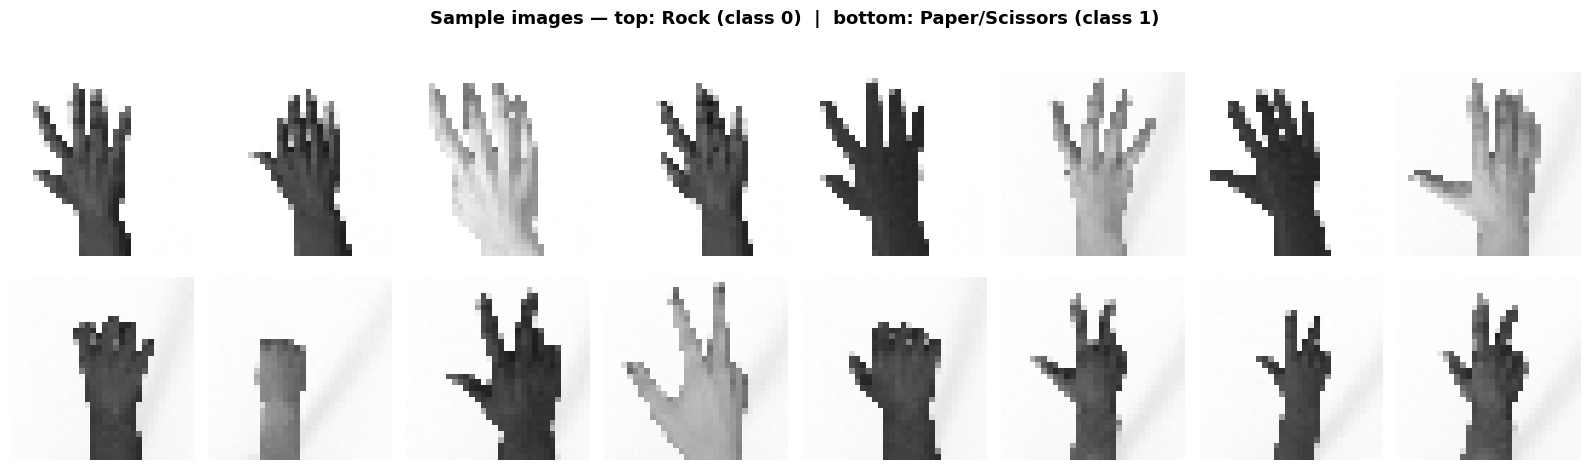

Saved → output/plots/dataset_samples.png


In [ ]:
try:
    import tensorflow_datasets as tfds
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "tensorflow-datasets", "-q"])
    import tensorflow_datasets as tfds

# ─── Load raw splits from TFDS ─────────────────────────────────────────────────
print("Loading Rock-Paper-Scissors dataset (downloads ~220 MB on first run) …")

(ds_train_raw, ds_test_raw), ds_info = tfds.load(
    "rock_paper_scissors",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    shuffle_files=False,          # we do our own shuffle below
)

print(f"  TFDS train examples : {ds_info.splits['train'].num_examples}")
print(f"  TFDS test  examples : {ds_info.splits['test'].num_examples}")
print(f"  Original classes    : {ds_info.features['label'].names}")  # ['paper','rock','scissors']

# ─── Preprocessing ─────────────────────────────────────────────────────────────
# Label mapping: rock=1 in TFDS → we remap so Rock=0, Not-Rock=1
# (TFDS label order is alphabetical: 0=paper, 1=rock, 2=scissors)

ROCK_LABEL_TFDS = 1   # index of 'rock' in TFDS label list

def preprocess_rps(img: tf.Tensor, label: tf.Tensor):
    """
    Resize to IMG_H×IMG_W, convert to grayscale, normalise to [0,1].
    Binary label: Rock → 0,  Paper/Scissors → 1
    """
    img   = tf.image.rgb_to_grayscale(img)                  # (300,300,3) → (300,300,1)
    img   = tf.image.resize(img, [IMG_H, IMG_W])            # → (32,32,1)
    img   = tf.cast(img, tf.float32) / 255.0
    label = tf.cast(tf.not_equal(label, ROCK_LABEL_TFDS), tf.int32)  # Rock=0, else=1
    return img, label

def tfds_to_numpy(ds) -> tuple[np.ndarray, np.ndarray]:
    """Convert a tf.data.Dataset of (img, label) to NumPy arrays."""
    imgs, labels = [], []
    for img, lbl in ds.map(preprocess_rps, num_parallel_calls=tf.data.AUTOTUNE):
        imgs.append(img.numpy())
        labels.append(int(lbl.numpy()))
    return np.array(imgs, dtype=np.float32), np.array(labels, dtype=np.int32)

print("\nPreprocessing train split …")
X_tfds_train, y_tfds_train = tfds_to_numpy(ds_train_raw)

print("Preprocessing test split …")
X_tfds_test,  y_tfds_test  = tfds_to_numpy(ds_test_raw)

# ─── Merge and shuffle (mirrors generate_dataset() output contract) ────────────
X_all = np.concatenate([X_tfds_train, X_tfds_test], axis=0)
y_all = np.concatenate([y_tfds_train, y_tfds_test], axis=0)

rng   = np.random.default_rng(SEED)
idx   = rng.permutation(len(y_all))
X_all = X_all[idx]
y_all = y_all[idx]

print(f"\n  Total samples  : {len(X_all)}")
print(f"  Shape          : {X_all.shape}")
print(f"  Rock (0) / Not-Rock (1) : {(y_all==0).sum()} / {(y_all==1).sum()}")
print(f"  Pixel range    : [{X_all.min():.3f}, {X_all.max():.3f}]")

# ─── Train / Validation / Test split (same ratios as before) ──────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, stratify=y_trainval, random_state=SEED
)

print(f"\n  Train   : {len(X_train):>5} samples")
print(f"  Val     : {len(X_val):>5} samples")
print(f"  Test    : {len(X_test):>5} samples")

# ─── Dataset visualisation (identical to original cell) ───────────────────────
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle(
    "Sample images — top: Rock (class 0)  |  bottom: Paper/Scissors (class 1)",
    fontsize=13, fontweight="bold"
)
rock_idx    = np.where(y_all == 0)[0][:8]
notrock_idx = np.where(y_all == 1)[0][:8]
for j in range(8):
    axes[0, j].imshow(X_all[rock_idx[j],    ..., 0], cmap="gray", vmin=0, vmax=1)
    axes[0, j].axis("off")
    axes[1, j].imshow(X_all[notrock_idx[j], ..., 0], cmap="gray", vmin=0, vmax=1)
    axes[1, j].axis("off")
plt.tight_layout()
plt.savefig(PLOT_DIR / "dataset_samples.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {PLOT_DIR / 'dataset_samples.png'}")

### Step 2 — Float32 Baseline CNN

Architecture:
```
Input (32×32×1)
  └─ Conv2D(8, 3×3, padding=same) → BN → ReLU
  └─ Conv2D(16, 3×3, padding=same) → BN → ReLU
  └─ GlobalAveragePooling2D
  └─ Dense(2, activation='softmax')
```
`padding='same'` keeps spatial dimensions constant, simplifying the RTL
addressing — the line buffer always operates on 32-wide rows.
BN is trained here; its parameters are folded into thresholds in Step 4.

Model: "BCNN_float32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 32, 32, 8)      │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 32, 32, 8)      │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 16)     │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 32, 32, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,354 (5.29 KB)

 Trainable params: 1,306 (5.10 KB)

 Non-trainable params: 48 (192.00 B)


Training for up to 30 epochs …
Epoch 1/30

Epoch 1: val_accuracy improved from None to 0.66667, saving model to output/models/float_best.keras

Epoch 1: finished saving model to output/models/float_best.keras
33/33 - 5s - 145ms/step - accuracy: 0.5759 - loss: 0.6784 - val_accuracy: 0.6667 - val_loss: 0.6344 - learning_rate: 0.0010
Epoch 2/30

Epoch 2: val_accuracy did not improve from 0.66667
33/33 - 3s - 86ms/step - accuracy: 0.6668 - loss: 0.6067 - val_accuracy: 0.6667 - val_loss: 0.6323 - learning_rate: 0.0010
Epoch 3/30

Epoch 3: val_accuracy did not improve from 0.66667
33/33 - 2s - 66ms/step - accuracy: 0.6697 - loss: 0.5850 - val_accuracy: 0.6667 - val_loss: 0.6278 - learning_rate: 0.0010
Epoch 4/30

Epoch 4: val_accuracy did not improve from 0.66667
33/33 - 2s - 75ms/step - accuracy: 0.6927 - loss: 0.5574 - val_accuracy: 0.6667 - val_loss: 0.6304 - learning_rate: 0.0010
Epoch 5/30

Epoch 5: val_accuracy did not improve from 0.66667
33/33 - 2s - 64ms/step - accuracy: 0.7338 - l

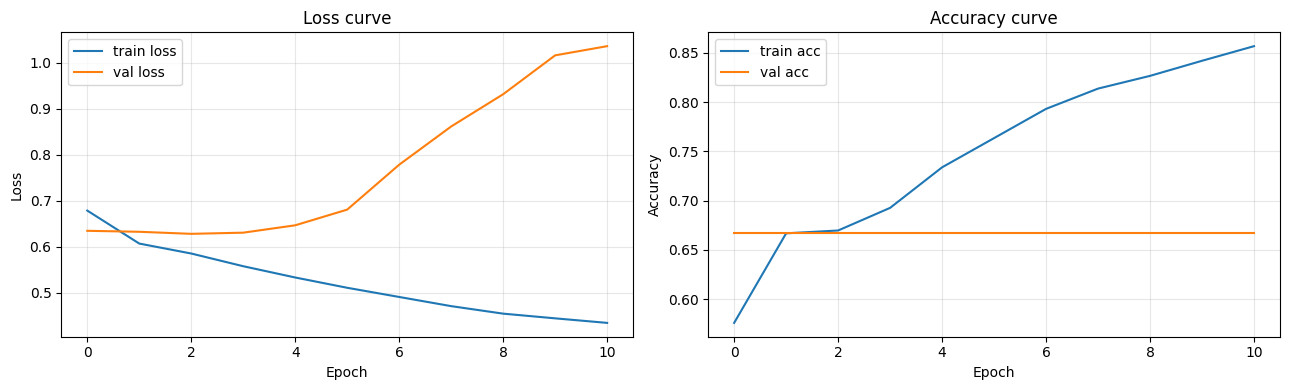


──────────────────────────────────────────────────
Float32 baseline — test accuracy : 66.59%
──────────────────────────────────────────────────
              precision    recall  f1-score   support

        Good       0.00      0.00      0.00       145
   Defective       0.67      1.00      0.80       289

    accuracy                           0.67       434
   macro avg       0.33      0.50      0.40       434
weighted avg       0.44      0.67      0.53       434



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


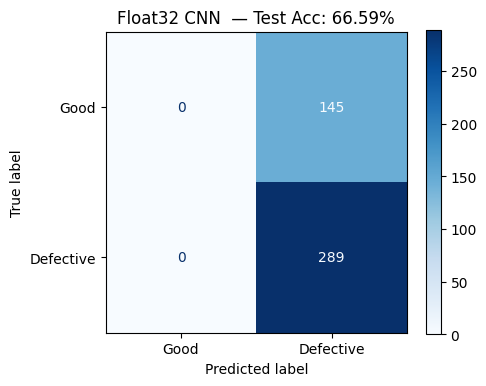

In [ ]:
def build_float_model(
    h: int = IMG_H,
    w: int = IMG_W,
    c: int = IMG_C,
    f1: int = CONV1_FILTERS,
    f2: int = CONV2_FILTERS,
    k: int = KERNEL_SIZE,
    num_classes: int = NUM_CLASSES,
) -> keras.Model:
    inp = keras.Input(shape=(h, w, c), name="input")

    # ── Layer 1 ──────────────────────────────────────────────────────────────
    x = layers.Conv2D(
        f1, (k, k), padding="same", use_bias=False, name="conv1"
    )(inp)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Activation("relu", name="relu1")(x)

    # ── Layer 2 ──────────────────────────────────────────────────────────────
    x = layers.Conv2D(
        f2, (k, k), padding="same", use_bias=False, name="conv2"
    )(inp if False else x)   # explicitly chained
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Activation("relu", name="relu2")(x)

    # ── Head ─────────────────────────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    out = layers.Dense(num_classes, activation="softmax", name="dense")(x)

    model = keras.Model(inputs=inp, outputs=out, name="BCNN_float32")
    return model


float_model = build_float_model()
float_model.summary()

# ─── Compile ──────────────────────────────────────────────────────────────────
float_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# ─── Callbacks ────────────────────────────────────────────────────────────────
ckpt_path  = str(MODEL_DIR / "float_best.keras")
cb_ckpt    = callbacks.ModelCheckpoint(
    ckpt_path, monitor="val_accuracy", save_best_only=True,
    mode="max", verbose=1
)
cb_lr      = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5, verbose=1
)
cb_early   = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=10, restore_best_weights=True, verbose=1
)

print(f"\nTraining for up to {EPOCHS} epochs …")
history = float_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[cb_ckpt, cb_lr, cb_early],
    verbose=2,
)

# ─── Training curves ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history.history["loss"],     label="train loss")
ax1.plot(history.history["val_loss"], label="val loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss curve"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history["accuracy"],     label="train acc")
ax2.plot(history.history["val_accuracy"], label="val acc")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy curve"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / "training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

# ─── Test-set evaluation ──────────────────────────────────────────────────────
y_pred_prob  = float_model.predict(X_test, verbose=0)
y_pred_float = np.argmax(y_pred_prob, axis=1)
float_acc    = accuracy_score(y_test, y_pred_float)

print(f"\n{'─'*50}")
print(f"Float32 baseline — test accuracy : {float_acc*100:.2f}%")
print(f"{'─'*50}")
print(classification_report(y_test, y_pred_float, target_names=["Good", "Defective"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_float)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Good", "Defective"]).plot(ax=ax, cmap="Blues")
ax.set_title(f"Float32 CNN  — Test Acc: {float_acc*100:.2f}%")
plt.tight_layout()
plt.savefig(PLOT_DIR / "float_confusion.png", dpi=120, bbox_inches="tight")
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Binarize Weights (Sign Function)
# ═══════════════════════════════════════════════════════════════════════════════

### Step 3 — Weight Binarization

**Rule**: `W_bin = sign(W_float)` where `sign(0) = +1`.

Mapping to hardware representation:
- `+1  →  binary bit 1`
- `−1  →  binary bit 0`

Only *convolutional kernels* are binarized.  BatchNorm parameters and the
Dense-layer weights are **not** binarized here; BN is folded in Step 4 and
the Dense layer (16→2) is small enough to keep in float (or fixed-point)
for final classification accuracy.

Conv1 weights
  Float  shape : (3, 3, 1, 8)   (kH, kW, C_in=1, C_out=8)
  Binary shape : (3, 3, 1, 8)
  Unique vals  : [-1  1]
  +1 fraction  : 48.6%
  -1 fraction  : 51.4%

Conv2 weights
  Float  shape : (3, 3, 8, 16)
  Binary shape : (3, 3, 8, 16)
  Unique vals  : [-1  1]
  +1 fraction  : 48.9%
  -1 fraction  : 51.1%


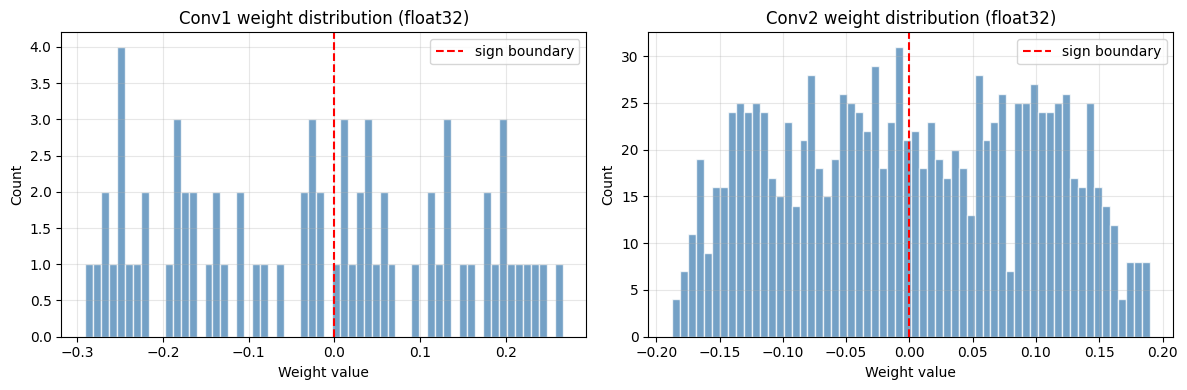


W1_bits unique: [0 1]  (0=minus1, 1=plus1)
W2_bits unique: [0 1]


In [ ]:
def extract_and_binarize_conv_weights(
    model: keras.Model,
    layer_name: str,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Extract float weights from a Conv2D layer and return:
      W_float : shape (kH, kW, C_in, C_out)  — float32, original
      W_bin   : shape (kH, kW, C_in, C_out)  — int8 in {-1, +1}

    Hardware bit: +1 → 1, −1 → 0  (i.e. (W_bin + 1) // 2 gives bits)
    """
    layer   = model.get_layer(layer_name)
    W_float = layer.get_weights()[0]            # Conv2D has no bias (use_bias=False)
    W_sign  = np.sign(W_float)
    W_sign[W_sign == 0] = 1                     # tie-break 0 → +1
    W_bin   = W_sign.astype(np.int8)            # values in {-1, +1}
    return W_float, W_bin


W1_float, W1_bin = extract_and_binarize_conv_weights(float_model, "conv1")
W2_float, W2_bin = extract_and_binarize_conv_weights(float_model, "conv2")

print("Conv1 weights")
print(f"  Float  shape : {W1_float.shape}   (kH, kW, C_in={W1_float.shape[2]}, C_out={W1_float.shape[3]})")
print(f"  Binary shape : {W1_bin.shape}")
print(f"  Unique vals  : {np.unique(W1_bin)}")
print(f"  +1 fraction  : {(W1_bin==1).mean()*100:.1f}%")
print(f"  -1 fraction  : {(W1_bin==-1).mean()*100:.1f}%")

print("\nConv2 weights")
print(f"  Float  shape : {W2_float.shape}")
print(f"  Binary shape : {W2_bin.shape}")
print(f"  Unique vals  : {np.unique(W2_bin)}")
print(f"  +1 fraction  : {(W2_bin==1).mean()*100:.1f}%")
print(f"  -1 fraction  : {(W2_bin==-1).mean()*100:.1f}%")

# ─── Weight magnitude distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, W, name in zip(axes, [W1_float, W2_float], ["Conv1", "Conv2"]):
    ax.hist(W.flatten(), bins=60, color="steelblue", alpha=0.75, edgecolor="white")
    ax.axvline(0, color="red", ls="--", lw=1.5, label="sign boundary")
    ax.set_title(f"{name} weight distribution (float32)")
    ax.set_xlabel("Weight value"); ax.set_ylabel("Count")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "weight_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

# Convert to hardware bit representation:  +1 → 1,  −1 → 0
W1_bits = ((W1_bin + 1) // 2).astype(np.uint8)   # shape (kH, kW, C_in, C_out)
W2_bits = ((W2_bin + 1) // 2).astype(np.uint8)

print(f"\nW1_bits unique: {np.unique(W1_bits)}  (0=minus1, 1=plus1)")
print(f"W2_bits unique: {np.unique(W2_bits)}")


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Fold BatchNorm into Integer Thresholds
# ═══════════════════════════════════════════════════════════════════════════════

### Step 4 — BatchNorm Folding

**Mathematics**

For a single output channel $f$ in a binary conv layer:

$$\text{dot}_f = \sum_{i} \hat{w}_{f,i} \cdot \hat{x}_i
  \quad \hat{w},\hat{x} \in \{-1,+1\}$$

After BatchNorm the pre-activation value is:

$$z_f = \gamma_f \cdot \frac{\text{dot}_f - \mu_f}{\sqrt{\sigma_f^2 + \varepsilon}} + \beta_f$$

The binarized output is $b_f = \text{sign}(z_f)$.

Since we only care about the **sign**, we can find the threshold $\theta_f$
(in *dot-product* space) such that $z_f > 0 \Leftrightarrow \text{dot}_f > \theta_f$:

$$\theta_f = \mu_f - \frac{\beta_f \cdot \sqrt{\sigma_f^2 + \varepsilon}}{\gamma_f}$$

*(when $\gamma_f > 0$; flip the comparison if $\gamma_f < 0$)*

Hardware uses XNOR-popcount.  The popcount $p$ relates to the dot product:

$$\text{dot} = 2p - N \quad (N = \text{number of elements in kernel window})$$

So the popcount threshold is:

$$\theta_f^{(pc)} = \left\lceil\frac{N + \theta_f^{(dot)}}{2}\right\rceil$$

We also record whether $\gamma_f < 0$ (a *flip* flag), because in that case
the comparison direction inverts.

Layer 1 — BatchNorm fold results
  N (kernel elements)    : 9
  Popcount thresholds    : [5 5 5 5 5 5 5 5]
  Dot-product thresholds : [-0.119 -0.151 -0.117  0.125 -0.233 -0.063  0.06   0.091]
  Flip flags (γ<0)       : [False False False False False False False False]
  gamma range            : [0.9797, 1.0128]

Layer 2 — BatchNorm fold results
  N (kernel elements)    : 72
  Popcount thresholds    : [37 36 37 37 36 37 36 36 37 37 36 36 37 36 36 37]
  Dot-product thresholds : [ 0.007 -0.027  0.009  0.046 -0.059  0.195 -0.096 -0.02   0.047  0.014
 -0.004 -0.022  0.054 -0.104 -0.101  0.008]
  Flip flags (γ<0)       : [False False False False False False False False False False False False
 False False False False]
  gamma range            : [0.9746, 1.0277]


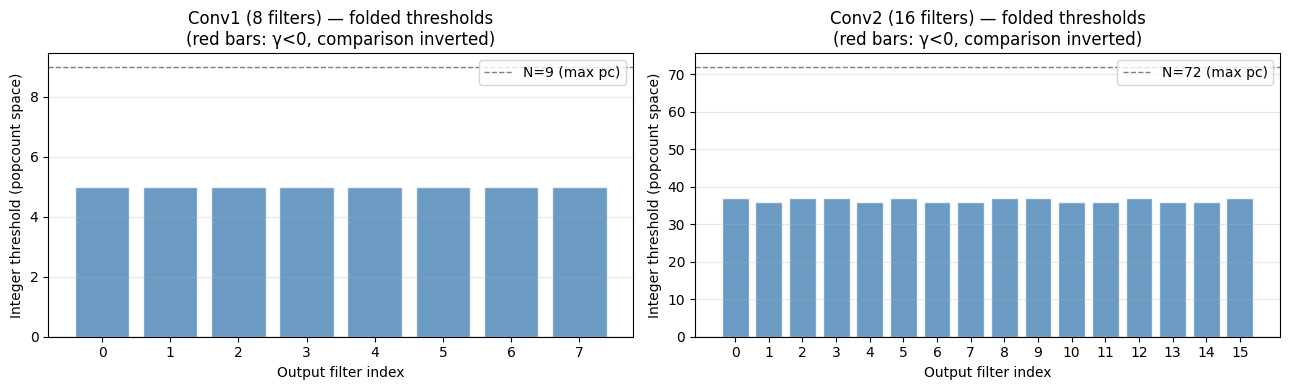

In [ ]:
def fold_batchnorm_thresholds(
    model: keras.Model,
    conv_name: str,
    bn_name: str,
    kernel_size: int = KERNEL_SIZE,
    n_in_channels: int = 1,
    epsilon_override: float | None = None,
) -> dict:
    """
    Compute per-output-channel integer thresholds for post-XNOR-popcount
    comparison, incorporating the full BatchNorm fold.

    Parameters
    ----------
    model          : trained Keras model
    conv_name      : name of the Conv2D layer (use_bias=False assumed)
    bn_name        : name of the paired BatchNorm layer
    kernel_size    : spatial kernel size k (assumes k×k)
    n_in_channels  : number of input channels to this conv layer
    epsilon_override : override BN epsilon (use None to read from layer)

    Returns
    -------
    dict with keys:
      thresholds_dot : float array (C_out,) — dot-product space thresholds
      thresholds_pc  : int   array (C_out,) — popcount space thresholds
      flip_flags     : bool  array (C_out,) — True when gamma < 0 (invert comparison)
      N              : int   — kernel elements per output (k*k*C_in)
      gamma, beta, mu, sigma2 : raw BN parameters for inspection
    """
    bn_layer   = model.get_layer(bn_name)
    gamma, beta, mu, sigma2 = bn_layer.get_weights()   # γ, β, running_mean, running_var
    eps = epsilon_override if epsilon_override is not None else bn_layer.epsilon

    N   = kernel_size * kernel_size * n_in_channels     # elements per kernel window

    sigma = np.sqrt(sigma2 + eps)

    # Threshold in dot-product space (dot > theta_dot  →  output = +1 when gamma>0)
    # z_f = gamma_f * (dot - mu_f) / sigma_f + beta_f
    # sign(z_f) = 1  ←→  gamma_f * (dot - mu_f) / sigma_f + beta_f > 0
    # If gamma_f > 0:  dot > mu_f - beta_f * sigma_f / gamma_f
    # If gamma_f < 0:  dot < mu_f - beta_f * sigma_f / gamma_f  (comparison flips)
    theta_dot  = mu - (beta * sigma / gamma)            # shape (C_out,)

    # Convert to popcount space:  dot = 2*pc - N  →  pc = (N + dot) / 2
    theta_pc_float = (N + theta_dot) / 2.0

    # Round: the RTL does  popcount >= threshold  →  output 1  (when gamma>0)
    # Ceiling gives the tightest integer threshold that preserves the inequality.
    theta_pc_int = np.ceil(theta_pc_float).astype(np.int32)

    # Clip to valid popcount range [0, N]
    theta_pc_int = np.clip(theta_pc_int, 0, N)

    flip_flags = (gamma < 0)

    return {
        "thresholds_dot" : theta_dot,
        "thresholds_pc"  : theta_pc_int,
        "flip_flags"     : flip_flags,
        "N"              : N,
        "gamma"          : gamma,
        "beta"           : beta,
        "mu"             : mu,
        "sigma2"         : sigma2,
        "eps"            : eps,
    }


# Layer 1: Conv(1→8), kernel 3×3 → N = 9
L1_thresh = fold_batchnorm_thresholds(
    float_model, "conv1", "bn1",
    kernel_size=KERNEL_SIZE, n_in_channels=IMG_C
)

# Layer 2: Conv(8→16), kernel 3×3 → N = 72
L2_thresh = fold_batchnorm_thresholds(
    float_model, "conv2", "bn2",
    kernel_size=KERNEL_SIZE, n_in_channels=CONV1_FILTERS
)

print("Layer 1 — BatchNorm fold results")
print(f"  N (kernel elements)    : {L1_thresh['N']}")
print(f"  Popcount thresholds    : {L1_thresh['thresholds_pc']}")
print(f"  Dot-product thresholds : {L1_thresh['thresholds_dot'].round(3)}")
print(f"  Flip flags (γ<0)       : {L1_thresh['flip_flags']}")
print(f"  gamma range            : [{L1_thresh['gamma'].min():.4f}, {L1_thresh['gamma'].max():.4f}]")

print("\nLayer 2 — BatchNorm fold results")
print(f"  N (kernel elements)    : {L2_thresh['N']}")
print(f"  Popcount thresholds    : {L2_thresh['thresholds_pc']}")
print(f"  Dot-product thresholds : {L2_thresh['thresholds_dot'].round(3)}")
print(f"  Flip flags (γ<0)       : {L2_thresh['flip_flags']}")
print(f"  gamma range            : [{L2_thresh['gamma'].min():.4f}, {L2_thresh['gamma'].max():.4f}]")

# ─── Threshold visualisation ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, info, name, n_filt in zip(
    axes,
    [L1_thresh, L2_thresh],
    ["Conv1 (8 filters)", "Conv2 (16 filters)"],
    [CONV1_FILTERS, CONV2_FILTERS]
):
    x_idx = np.arange(n_filt)
    bars  = ax.bar(x_idx, info["thresholds_pc"],
                   color=["tomato" if f else "steelblue" for f in info["flip_flags"]],
                   alpha=0.8, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    ax.axhline(info["N"], color="gray", ls="--", lw=1, label=f"N={info['N']} (max pc)")
    ax.set_xticks(x_idx)
    ax.set_xlabel("Output filter index"); ax.set_ylabel("Integer threshold (popcount space)")
    ax.set_title(f"{name} — folded thresholds\n(red bars: γ<0, comparison inverted)")
    ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(PLOT_DIR / "bn_folded_thresholds.png", dpi=120, bbox_inches="tight")
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Generate .mif Files for Quartus ROMs
# ═══════════════════════════════════════════════════════════════════════════════

### Step 5 — Quartus Memory Initialization Files (.mif)

One `.mif` per ROM:
- `conv1_weights.mif` : Layer-1 binarized kernel bits
- `conv2_weights.mif` : Layer-2 binarized kernel bits
- `conv1_thresh.mif`  : Layer-1 integer thresholds
- `conv2_thresh.mif`  : Layer-2 integer thresholds
- `conv1_flip.mif`    : Layer-1 flip flags (1-bit per channel)
- `conv2_flip.mif`    : Layer-2 flip flags

**Addressing convention for weight ROMs**

Each address encodes one kernel "slice": all bits for filter *f* at position
*(r, c, c_in)*.  The RTL fetches the weight bit for a given output channel
by indexing: `addr = f * K * K * C_in + cin * K * K + row * K + col`.
Each word is 1-bit wide — the simplest for FPGA LUT-based ROM inference.

In [ ]:
# ─────────────────────────────────────────────────────────────
# HEX writer (ModelSim / $readmemh compatible)
# ─────────────────────────────────────────────────────────────
def write_hex(path: Path, data: np.ndarray, bits: int):
    """
    Writes raw hex file (no headers), one value per line.
    Compatible with $readmemh.

    bits: width of each entry (1, 8, 16, etc.)
    """
    with open(path, "w") as f:
        for val in data.flatten():
            v = int(val) & ((1 << bits) - 1)
            hex_width = (bits + 3) // 4
            f.write(f"{v:0{hex_width}X}\n")

    print(f"  HEX written: {path} (width={bits})")

# Conv1: 8 filters, each 9 bits → one 3-digit hex word per filter
def write_hex_packed(path, W_bits, n_filters, bits_per_filter):
    """Pack all bits for one filter into a single hex word per line."""
    flat = W_bits.flatten()
    hex_digits = (bits_per_filter + 3) // 4
    with open(path, "w") as f:
        for filt in range(n_filters):
            word = 0
            for b in range(bits_per_filter):
                word = (word << 1) | int(flat[filt * bits_per_filter + b])
            f.write(f"{word:0{hex_digits}X}\n")
    print(f"  HEX written: {path} ({n_filters} lines, {bits_per_filter} bits each)")

N1 = KERNEL_SIZE * KERNEL_SIZE * IMG_C        # 9
N2 = KERNEL_SIZE * KERNEL_SIZE * CONV1_FILTERS  # 72


def write_mif(
    path: Path,
    data: np.ndarray,
    word_bits: int,
    radix: str = "BIN",
    comment: str = "",
) -> None:
    """
    Write a Quartus .mif file.

    Parameters
    ----------
    path      : output file path
    data      : 1-D integer array (values must fit in word_bits)
    word_bits : ROM word width in bits
    radix     : 'BIN', 'HEX', or 'DEC'
    comment   : optional comment line in file header
    """
    depth  = len(data)
    addr_w = max(1, math.ceil(math.log2(max(depth, 2))))

    with open(path, "w") as f:
        f.write(f"-- {comment}\n")
        f.write(f"-- Auto-generated by BCNN Phase A notebook\n")
        f.write(f"-- DO NOT EDIT MANUALLY\n\n")
        f.write(f"DEPTH = {depth};\n")
        f.write(f"WIDTH = {word_bits};\n")
        f.write(f"ADDRESS_RADIX = HEX;\n")
        f.write(f"DATA_RADIX = {radix};\n\n")
        f.write("CONTENT BEGIN\n")

        for addr, val in enumerate(data):
            val = int(val)
            if radix == "BIN":
                val_str = format(val & ((1 << word_bits) - 1), f"0{word_bits}b")
            elif radix == "HEX":
                hex_digits = math.ceil(word_bits / 4)
                val_str = format(val & ((1 << word_bits) - 1), f"0{hex_digits}X")
            else:  # DEC
                val_str = str(val)
            addr_str = format(addr, f"0{max(1, addr_w // 4)}X")
            f.write(f"\t{addr_str} : {val_str};\n")

        f.write("END;\n")

    print(f"  Written: {path}  (depth={depth}, width={word_bits} bits, radix={radix})")

# ─────────────────────────────────────────────────────────────
# Generate .bin files for flip flags (for $readmemb)
# ─────────────────────────────────────────────────────────────
def write_bin(path: Path, data: np.ndarray):
    """
    Writes 1-bit values (0/1) per line for $readmemb
    """
    with open(path, "w") as f:
        for val in data.flatten():
            f.write(f"{int(val)}\n")   # must be '0' or '1'

    print(f"  Written: {path}")




# ─── Helper: flatten weights into 1-D bit array ───────────────────────────────
def flatten_weights_to_bits(
    W_bits: np.ndarray,
) -> np.ndarray:
    """
    Flatten (kH, kW, C_in, C_out) weight-bit tensor to 1D array.

    Addressing: filter-major ordering.
    addr = f * (kH * kW * C_in) + cin * (kH * kW) + row * kW + col

    Each element is a single bit (0 or 1) stored as uint8.
    This gives one address per bit, width=1 in the MIF.
    """
    kH, kW, C_in, C_out = W_bits.shape
    # Reorder to (C_out, C_in, kH, kW) then flatten
    W_reorder = W_bits.transpose(3, 2, 0, 1)          # (C_out, C_in, kH, kW)
    return W_reorder.flatten().astype(np.uint8)


# ─── Weight ROMs ──────────────────────────────────────────────────────────────
print("\nGenerating weight ROMs …")
W1_flat = flatten_weights_to_bits(W1_bits)
W2_flat = flatten_weights_to_bits(W2_bits)

print(f"  Conv1 weight bits : {len(W1_flat)}  "
      f"({CONV1_FILTERS} filters × {KERNEL_SIZE*KERNEL_SIZE*IMG_C} elements)")
print(f"  Conv2 weight bits : {len(W2_flat)}  "
      f"({CONV2_FILTERS} filters × {KERNEL_SIZE*KERNEL_SIZE*CONV1_FILTERS} elements)")

# # HEX export for simulation
N1 = KERNEL_SIZE * KERNEL_SIZE * IMG_C        # 9
N2 = KERNEL_SIZE * KERNEL_SIZE * CONV1_FILTERS  # 72
write_hex_packed(HEX_DIR / "conv1_weights.hex", W1_flat, CONV1_FILTERS, N1)
write_hex_packed(HEX_DIR / "conv2_weights.hex", W2_flat, CONV2_FILTERS, N2)

# ─── Threshold ROMs ───────────────────────────────────────────────────────────
# Thresholds are signed integers in [0, N].
# N_L1 = 9   → needs 4 bits to represent [0..9]
# N_L2 = 72  → needs 7 bits to represent [0..72]
# We use 8-bit words for both (signed, two's complement).

print("\nGenerating threshold ROMs …")

def signed_to_twos_complement(arr: np.ndarray, bits: int) -> np.ndarray:
    """Convert signed int array to unsigned two's-complement representation."""
    mask = (1 << bits) - 1
    return (arr.astype(np.int32) & mask).astype(np.uint32)


COUNT_W_L1 = math.ceil(math.log2(N1 + 2))  # $clog2(10) = 4 bits → 1 hex digit
COUNT_W_L2 = math.ceil(math.log2(N2 + 2))  # $clog2(73) = 7 bits → 2 hex digits

L1_th_tc = signed_to_twos_complement(L1_thresh["thresholds_pc"], bits=COUNT_W_L1)
L2_th_tc = signed_to_twos_complement(L2_thresh["thresholds_pc"], bits=COUNT_W_L2)

write_hex(HEX_DIR / "conv1_thresh.hex", L1_th_tc, bits=COUNT_W_L1)
write_hex(HEX_DIR / "conv2_thresh.hex", L2_th_tc, bits=COUNT_W_L2)

# ─── Flip-flag ROMs (1-bit: 1 = invert comparison because γ < 0) ──────────────
print("\nGenerating flip-flag ROMs …")
L1_flip = L1_thresh["flip_flags"].astype(np.uint8)
L2_flip = L2_thresh["flip_flags"].astype(np.uint8)

# write_mif(
#     MEM_DIR / "conv1_flip.mif", L1_flip,
#     word_bits=1, radix="BIN",
#     comment="Conv1 gamma-sign flags: 1 → invert popcount comparison"
# )
# write_mif(
#     MEM_DIR / "conv2_flip.mif", L2_flip,
#     word_bits=1, radix="BIN",
#     comment="Conv2 gamma-sign flags: 1 → invert popcount comparison"
# )
# Generate files
write_bin(HEX_DIR / "conv1_flip.bin", L1_flip)
write_bin(HEX_DIR / "conv2_flip.bin", L2_flip)

# ─── Export a JSON manifest for the RTL team ──────────────────────────────────
manifest = {
    "image"      : {"H": IMG_H, "W": IMG_W, "C": IMG_C},
    "layer1"     : {
        "mif_weights"  : "mem/conv1_weights.mif",
        "mif_thresh"   : "mem/conv1_thresh.mif",
        "mif_flip"     : "mem/conv1_flip.mif",
        "C_in"         : int(IMG_C),
        "C_out"        : int(CONV1_FILTERS),
        "kernel"       : int(KERNEL_SIZE),
        "N"            : int(L1_thresh["N"]),
        "thresholds"   : L1_thresh["thresholds_pc"].tolist(),
        "flip_flags"   : L1_thresh["flip_flags"].tolist(),
    },
    "layer2"     : {
        "mif_weights"  : "mem/conv2_weights.mif",
        "mif_thresh"   : "mem/conv2_thresh.mif",
        "mif_flip"     : "mem/conv2_flip.mif",
        "C_in"         : int(CONV1_FILTERS),
        "C_out"        : int(CONV2_FILTERS),
        "kernel"       : int(KERNEL_SIZE),
        "N"            : int(L2_thresh["N"]),
        "thresholds"   : L2_thresh["thresholds_pc"].tolist(),
        "flip_flags"   : L2_thresh["flip_flags"].tolist(),
    },
    "dense": {
        "weights_0": "hex/dense_w0.hex",
        "weights_1": "hex/dense_w1.hex",
        "bias": "hex/dense_b.hex",
        "format": "Q8.8"
    },
    "input_binarization_threshold" : int(INPUT_BIN_THRESHOLD),
}

manifest_path = OUTPUT_DIR / "rtl_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)
print(f"\n  RTL manifest → {manifest_path}")


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 6 — Convert Test Images to Hex (ModelSim $readmemh)
# ═══════════════════════════════════════════════════════════════════════════════


Generating weight ROMs …
  Conv1 weight bits : 72  (8 filters × 9 elements)
  Conv2 weight bits : 1152  (16 filters × 72 elements)
  HEX written: output/hex/conv1_weights.hex (8 lines, 9 bits each)
  HEX written: output/hex/conv2_weights.hex (16 lines, 72 bits each)

Generating threshold ROMs …
  HEX written: output/hex/conv1_thresh.hex (width=4)
  HEX written: output/hex/conv2_thresh.hex (width=7)

Generating flip-flag ROMs …
  Written: output/hex/conv1_flip.bin
  Written: output/hex/conv2_flip.bin

  RTL manifest → output/rtl_manifest.json


### Step 6 — Test Image → Hex Conversion

The RTL testbench will load pixel streams using `$readmemh`.
Format: one **byte per line**, big-endian row-major scan order (row 0 → row H-1,
within each row col 0 → col W-1).

We also emit:
- `labels.txt` — one integer per line (0=good, 1=defective)
- `image_preview.png` — visual confirmation of selected images

Wrote 10 hex image files to output/hex/
Labels written → output/hex/labels.txt

Label distribution: Good=5, Defective=5
  Image 00: label=1 (Defective)  → test_image_00.hex
  Image 01: label=0 (Good     )  → test_image_01.hex
  Image 02: label=1 (Defective)  → test_image_02.hex
  Image 03: label=1 (Defective)  → test_image_03.hex
  Image 04: label=0 (Good     )  → test_image_04.hex
  Image 05: label=0 (Good     )  → test_image_05.hex
  Image 06: label=1 (Defective)  → test_image_06.hex
  Image 07: label=0 (Good     )  → test_image_07.hex
  Image 08: label=1 (Defective)  → test_image_08.hex
  Image 09: label=0 (Good     )  → test_image_09.hex

Verifying hex round-trip …
  Round-trip check: PASS ✓


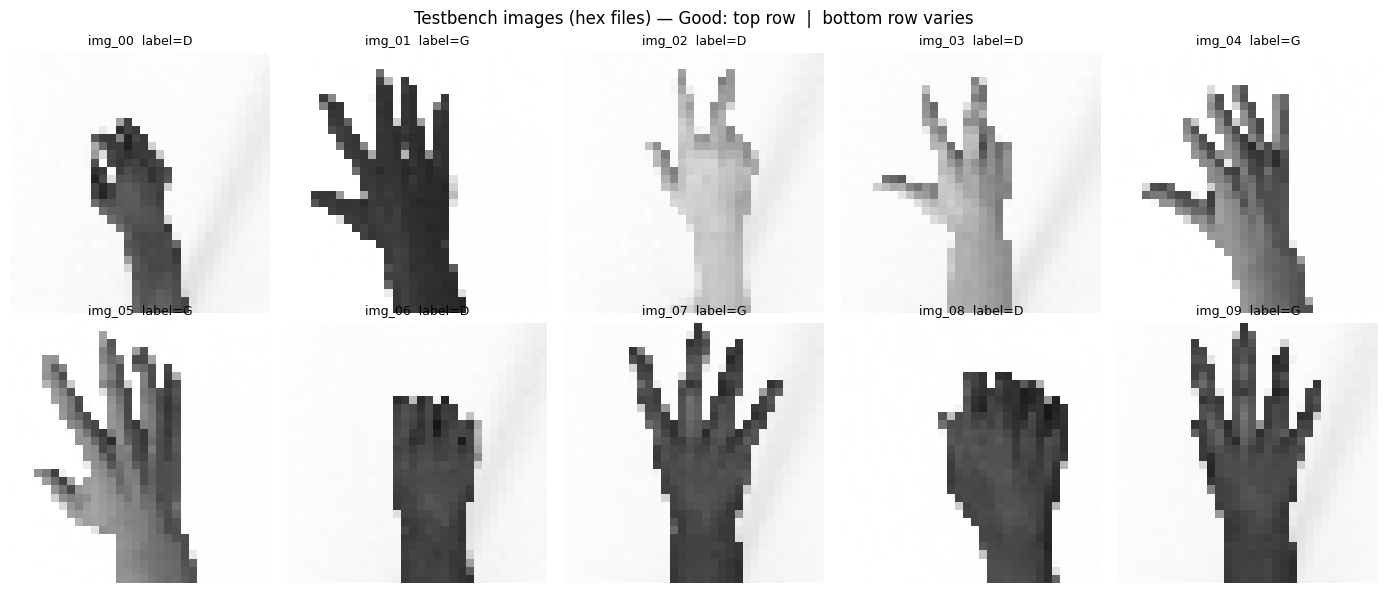


Verilog parameter header → output/hex/tb_params.vh


In [ ]:
N_TEST_IMAGES = 10     # number of representative images for testbench

# Select 5 good and 5 defective from the test set
rng = np.random.default_rng(SEED + 1)
good_sel = rng.choice(np.where(y_test == 0)[0], size=N_TEST_IMAGES // 2, replace=False)
def_sel  = rng.choice(np.where(y_test == 1)[0], size=N_TEST_IMAGES // 2, replace=False)
sel_idx  = np.concatenate([good_sel, def_sel])
rng.shuffle(sel_idx)

X_tb = X_test[sel_idx]    # shape (10, 32, 32, 1), float32 [0,1]
y_tb = y_test[sel_idx]    # shape (10,)

# Convert to uint8 [0,255]
X_tb_u8 = (X_tb[..., 0] * 255).astype(np.uint8)  # shape (10, 32, 32)

# Write hex files
label_lines = []
for i in range(N_TEST_IMAGES):
    hex_path = HEX_DIR / f"test_image_{i:02d}.hex"
    pixels   = X_tb_u8[i].flatten()               # 1024 bytes for 32×32
    with open(hex_path, "w") as f:
        for px in pixels:
            f.write(f"{px:02X}\n")
    label_lines.append(str(y_tb[i]))

label_path = HEX_DIR / "labels.txt"
with open(label_path, "w") as f:
    f.write("\n".join(label_lines) + "\n")

print(f"Wrote {N_TEST_IMAGES} hex image files to {HEX_DIR}/")
print(f"Labels written → {label_path}")
print(f"\nLabel distribution: Good={sum(y_tb==0)}, Defective={sum(y_tb==1)}")
for i, (lbl, path) in enumerate(zip(y_tb, [HEX_DIR / f"test_image_{i:02d}.hex" for i in range(N_TEST_IMAGES)])):
    print(f"  Image {i:02d}: label={lbl} ({'Good     ' if lbl==0 else 'Defective'})  → {path.name}")

# ─── Verify hex round-trip ────────────────────────────────────────────────────
print("\nVerifying hex round-trip …")
all_ok = True
for i in range(N_TEST_IMAGES):
    hex_path = HEX_DIR / f"test_image_{i:02d}.hex"
    with open(hex_path, "r") as f:
        loaded = np.array([int(line.strip(), 16) for line in f if line.strip()], dtype=np.uint8)
    expected = X_tb_u8[i].flatten()
    if not np.array_equal(loaded, expected):
        print(f"  FAIL image {i:02d}: mismatch!")
        all_ok = False
print(f"  Round-trip check: {'PASS ✓' if all_ok else 'FAIL ✗'}")

# ─── Image preview ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Testbench images (hex files) — Good: top row  |  bottom row varies", fontsize=12)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_tb_u8[i], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"img_{i:02d}  label={'G' if y_tb[i]==0 else 'D'}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig(PLOT_DIR / "testbench_images.png", dpi=120, bbox_inches="tight")
plt.show()

# ─── Write a Verilog-ready parameter header ───────────────────────────────────
# This file can be `include`d in the testbench
tb_params_path = HEX_DIR / "tb_params.vh"
with open(tb_params_path, "w") as f:
    f.write("// Auto-generated testbench parameters — DO NOT EDIT MANUALLY\n")
    f.write(f"// Generated by BCNN Phase A notebook\n\n")
    f.write(f"`define IMG_H              {IMG_H}\n")
    f.write(f"`define IMG_W              {IMG_W}\n")
    f.write(f"`define IMG_PIXELS         {IMG_H * IMG_W}\n")
    f.write(f"`define N_TEST_IMAGES      {N_TEST_IMAGES}\n")
    f.write(f"`define INPUT_BIN_THRESH   {INPUT_BIN_THRESHOLD}\n")
    f.write(f"`define CONV1_FILTERS      {CONV1_FILTERS}\n")
    f.write(f"`define CONV2_FILTERS      {CONV2_FILTERS}\n")
    f.write(f"`define KERNEL_SIZE        {KERNEL_SIZE}\n")
    f.write(f"`define L1_N               {L1_thresh['N']}\n")
    f.write(f"`define L2_N               {L2_thresh['N']}\n")
    f.write(f"// Ground-truth labels (0=good, 1=defective)\n")
    f.write(f"// image 00..{N_TEST_IMAGES-1:02d}: {','.join(map(str, y_tb))}\n")
print(f"\nVerilog parameter header → {tb_params_path}")


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 7 — Software-Binarized Model Accuracy (Golden Reference)
# ═══════════════════════════════════════════════════════════════════════════════

### Step 7 — Software-Simulated Binarized Inference

This section implements the *exact* integer arithmetic that the RTL will
perform, in Python/NumPy.  If the RTL produces a different classification for
any test image, there is a hardware bug — not a model accuracy issue.

Pipeline per image:
```
1. Binarize input pixels    : px >= INPUT_BIN_THRESHOLD  →  +1  else  -1
2. Layer 1: XNOR-popcount   : sliding 3×3 window, W1_bin (8 filters)
            Compare vs threshold, apply flip flag  →  1-bit output map (H×W×8)
3. Layer 2: XNOR-popcount   : same, W2_bin (16 filters)
            Compare vs threshold  →  1-bit output map (H×W×16)
4. Global average pooling   : popcount across spatial dims per channel
5. Dense layer              : keep float for final scoring (W_dense × float)
6. Argmax                   →  predicted class
```

The dense layer is small (16 inputs × 2 outputs), so we keep it full-precision.

In [ ]:
# ─── Extract dense-layer weights ──────────────────────────────────────────────
dense_layer  = float_model.get_layer("dense")
W_dense, b_dense = dense_layer.get_weights()   # (16, 2), (2,)
print(f"Dense weight shape : {W_dense.shape}")
print(f"Dense bias   shape : {b_dense.shape}")

Q_SCALE = 256   # Q8.8
INT16_MIN, INT16_MAX = -32768, 32767

def to_q8_8(x: np.ndarray) -> np.ndarray:
    x_scaled = np.round(x * Q_SCALE)
    x_clipped = np.clip(x_scaled, INT16_MIN, INT16_MAX)
    return x_clipped.astype(np.int16)


# Quantize
Wq = to_q8_8(W_dense)   # (16,2)
bq = to_q8_8(b_dense)   # (2,)

Dense weight shape : (16, 2)
Dense bias   shape : (2,)


Running software-binarized inference on test set …
(This is O(H*W*C*K*K) per image — may take ~1 min for 600 images)

  Processed 100/434 images …
  Processed 200/434 images …
  Processed 300/434 images …
  Processed 400/434 images …

────────────────────────────────────────────────────────────
Float32 baseline accuracy   : 66.59%
Software-binarized accuracy : 33.41%
Accuracy drop (expected)    : 33.18 pp
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

        Good       0.33      1.00      0.50       145
   Defective       0.00      0.00      0.00       289

    accuracy                           0.33       434
   macro avg       0.17      0.50      0.25       434
weighted avg       0.11      0.33      0.17       434



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


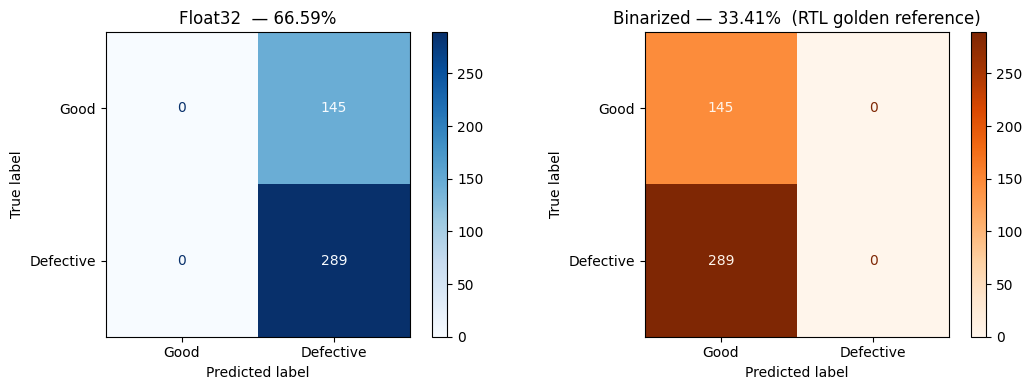


Golden reference for testbench images:
 Img     Label      Pred   Correct?    Logit[0]    Logit[1]
──────────────────────────────────────────────────────────────
  00  Defective  Good              ✗   8465.0000  -16442.0000
  01  Good      Good              ✓    449.0000  -9588.0000
  02  Defective  Good              ✗  14692.0000  -23586.0000
  03  Defective  Good              ✗   5179.0000  -15784.0000
  04  Good      Good              ✓   1563.0000  -8821.0000
  05  Good      Good              ✓   3072.0000  -12742.0000
  06  Defective  Good              ✗   8482.0000  -15923.0000
  07  Good      Good              ✓     96.0000  -10646.0000
  08  Defective  Good              ✗   3367.0000  -8299.0000
  09  Good      Good              ✓   2745.0000  -12827.0000

  Testbench accuracy: 50.0%  (5/10)

Golden output reference → output/hex/golden_outputs.txt


In [14]:
def binarize_pixels(img_float: np.ndarray, threshold: int = INPUT_BIN_THRESHOLD) -> np.ndarray:
    """
    img_float : (H, W) float32 in [0,1]
    Returns   : (H, W) int8 in {-1, +1}
    """
    px_u8 = (img_float * 255).astype(np.uint8)
    return np.where(px_u8 >= threshold, np.int8(1), np.int8(-1))


def xnor_popcount_conv2d(
    act_bin   : np.ndarray,    # (H, W, C_in) int8 in {-1, +1}
    W_bin     : np.ndarray,    # (kH, kW, C_in, C_out) int8 in {-1, +1}
    thresholds: np.ndarray,    # (C_out,) int32
    flip_flags: np.ndarray,    # (C_out,) bool
    padding   : str = "same",
) -> np.ndarray:
    """
    Binary convolution via XNOR-popcount with folded BN threshold.

    Returns (H_out, W_out, C_out) int8 in {-1, +1} (the binarized output activation).

    'same' padding mirrors RTL behaviour: pads with -1 (the "zero" in binary
    space, i.e., the value that contributes 0 to the popcount agreement).
    """
    H, W, C_in   = act_bin.shape
    kH, kW, _, C_out = W_bin.shape
    pad_h = (kH - 1) // 2
    pad_w = (kW - 1) // 2

    if padding == "same":
        # Pad with -1 (binary "zero" — won't match any weight, contributes 0 to popcount)
        padded = np.pad(
            act_bin, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)),
            mode="constant", constant_values=-1
        )
    else:
        padded = act_bin

    H_out = H if padding == "same" else H - kH + 1
    W_out = W if padding == "same" else W - kW + 1

    out_bin = np.zeros((H_out, W_out, C_out), dtype=np.int8)

    for r in range(H_out):
        for c in range(W_out):
            window = padded[r:r+kH, c:c+kW, :]        # (kH, kW, C_in)
            for f in range(C_out):
                kernel = W_bin[:, :, :, f]             # (kH, kW, C_in)
                # XNOR: agreement when both are same sign → xnor(a,b) = (a*b+1)//2 in {0,1}
                xnor   = (window * kernel + 1) // 2    # {0,1} — agreeing positions
                pc     = int(xnor.sum())               # popcount = number of agreements
                thr    = int(thresholds[f])
                flip   = bool(flip_flags[f])
                # Default: output +1 if pc >= threshold (gamma > 0)
                # Flipped: output +1 if pc <  threshold (gamma < 0)
                if not flip:
                    out_bin[r, c, f] = np.int8(1) if pc >= thr else np.int8(-1)
                else:
                    out_bin[r, c, f] = np.int8(1) if pc <  thr else np.int8(-1)

    return out_bin


def global_average_pool_binary(act_bin: np.ndarray) -> np.ndarray:
    """
    act_bin : (H, W, C) int8 in {-1, +1}
    Returns : (C,) float32  — fraction of +1 activations (acts as float GAP)

    For binary output: the "average" is the popcount of +1s divided by H*W.
    We return a float to feed into the full-precision Dense layer.
    """
    H, W, C = act_bin.shape
    return act_bin.mean(axis=(0, 1)).astype(np.float32)   # (C,) in [-1, +1]


def bcnn_infer(
    img_float  : np.ndarray,   # (H, W) float32 [0,1]
    W1_bin     : np.ndarray,
    L1_info    : dict,
    W2_bin     : np.ndarray,
    L2_info    : dict,
    W_dense    : np.ndarray,
    b_dense    : np.ndarray,
    pixel_thr  : int = INPUT_BIN_THRESHOLD,
) -> tuple[int, np.ndarray]:
    """
    Full binarized inference pipeline.

    Returns (predicted_class, logits).
    """
    # 1. Pixel binarization
    x_bin = binarize_pixels(img_float, threshold=pixel_thr)  # (H, W) int8 {-1,+1}
    x_bin = x_bin[..., np.newaxis]                           # (H, W, 1)

    # 2. Layer 1 binary convolution
    x1 = xnor_popcount_conv2d(
        x_bin, W1_bin,
        L1_info["thresholds_pc"], L1_info["flip_flags"],
        padding="same"
    )   # (H, W, C1)

    # 3. Layer 2 binary convolution
    x2 = xnor_popcount_conv2d(
        x1, W2_bin,
        L2_info["thresholds_pc"], L2_info["flip_flags"],
        padding="same"
    )   # (H, W, C2)

    # 4. Global average pooling
    gap = global_average_pool_binary(x2)   # (C2,) float32

    # 5. Dense layer (float)

    # ─────────────────────────────────────────────────────────────
    # FIX 2 — Quantized dense inference (bit-accurate to RTL)
    # ─────────────────────────────────────────────────────────────

    gap_q = to_q8_8(gap)  # quantize GAP output

    logits_q = np.zeros(2, dtype=np.int32)

    for i in range(2):
        acc = np.int32(0)
        for j in range(len(gap_q)):
            acc += np.int32(gap_q[j]) * np.int32(Wq[j, i])
        acc += np.int32(bq[i])
        logits_q[i] = acc

    pred = int(np.argmax(logits_q))
    return pred, logits_q


# ─── Run software-binarized inference on full test set ────────────────────────
print("Running software-binarized inference on test set …")
print("(This is O(H*W*C*K*K) per image — may take ~1 min for 600 images)\n")

y_pred_bin = []
logit_list = []

for i, (img, label) in enumerate(zip(X_test[..., 0], y_test)):
    pred, logits = bcnn_infer(
        img, W1_bin, L1_thresh, W2_bin, L2_thresh, W_dense, b_dense
    )
    y_pred_bin.append(pred)
    logit_list.append(logits)
    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/{len(X_test)} images …")

y_pred_bin = np.array(y_pred_bin)
bin_acc    = accuracy_score(y_test, y_pred_bin)

print(f"\n{'─'*60}")
print(f"Float32 baseline accuracy   : {float_acc*100:.2f}%")
print(f"Software-binarized accuracy : {bin_acc*100:.2f}%")
print(f"Accuracy drop (expected)    : {(float_acc - bin_acc)*100:.2f} pp")
print(f"{'─'*60}")
print(classification_report(y_test, y_pred_bin, target_names=["Good", "Defective"]))

# Confusion matrix comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_float),
    display_labels=["Good", "Defective"]
).plot(ax=ax1, cmap="Blues")
ax1.set_title(f"Float32  — {float_acc*100:.2f}%")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_bin),
    display_labels=["Good", "Defective"]
).plot(ax=ax2, cmap="Oranges")
ax2.set_title(f"Binarized — {bin_acc*100:.2f}%  (RTL golden reference)")
plt.tight_layout()
plt.savefig(PLOT_DIR / "confusion_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


# ─── Run on testbench images and produce golden expected outputs ───────────────
print("\nGolden reference for testbench images:")
print(f"{'Img':>4}  {'Label':>8}  {'Pred':>8}  {'Correct?':>9}  {'Logit[0]':>10}  {'Logit[1]':>10}")
print("─" * 62)

tb_results = []
for i in range(N_TEST_IMAGES):
    img    = X_tb[i, ..., 0]
    label  = int(y_tb[i])
    pred, logits = bcnn_infer(
        img, W1_bin, L1_thresh, W2_bin, L2_thresh, W_dense, b_dense
    )
    correct = (pred == label)
    tb_results.append({"img_idx": i, "label": label, "pred": pred, "correct": correct})
    sym = "✓" if correct else "✗"
    print(f"  {i:02d}  {'Good    ' if label==0 else 'Defective':>8}  "
          f"{'Good    ' if pred==0 else 'Defective':>8}  {sym:>9}  "
          f"{logits[0]:>10.4f}  {logits[1]:>10.4f}")

tb_acc = sum(r["correct"] for r in tb_results) / N_TEST_IMAGES
print(f"\n  Testbench accuracy: {tb_acc*100:.1f}%  ({sum(r['correct'] for r in tb_results)}/{N_TEST_IMAGES})")

# Write golden output file for testbench automated checking
golden_path = HEX_DIR / "golden_outputs.txt"
with open(golden_path, "w") as f:
    f.write("// Golden expected outputs for RTL testbench\n")
    f.write("// Format: img_index  gt_label  expected_pred\n")
    for r in tb_results:
        f.write(f"{r['img_idx']:02d}  {r['label']}  {r['pred']}\n")
print(f"\nGolden output reference → {golden_path}")


# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY — Accuracy Report & File Manifest
# ═══════════════════════════════════════════════════════════════════════════════

In [15]:
# ─────────────────────────────────────────────────────────────
# FIX 1 — Dense layer export (Q8.8 fixed-point)
# ─────────────────────────────────────────────────────────────

def write_hex_file(path: Path, data: np.ndarray):
    with open(path, "w") as f:
        for val in data.flatten():
            val_int = int(val)                  # ← CRITICAL FIX
            val_u16 = val_int & 0xFFFF          # now safe
            f.write(f"{val_u16:04X}\n")


# Split per output neuron (IMPORTANT for RTL)
write_hex_file(HEX_DIR / "dense_w0.hex", Wq[:, 0])
write_hex_file(HEX_DIR / "dense_w1.hex", Wq[:, 1])
write_hex_file(HEX_DIR / "dense_b.hex",  bq)

print("Dense layer exported (Q8.8) → HEX/")

Dense layer exported (Q8.8) → HEX/


### Summary

In [16]:
print("\n" + "═"*65)
print("  BCNN Phase A — COMPLETE SUMMARY")
print("═"*65)

print(f"\n  MODEL ACCURACY")
print(f"  ──────────────────────────────────────────")
print(f"  Float32 baseline (Keras)     : {float_acc*100:.2f}%")
print(f"  Binarized model (SW sim)     : {bin_acc*100:.2f}%   ← RTL golden reference")
print(f"  Accuracy drop                : {(float_acc-bin_acc)*100:.2f} percentage points")

print(f"\n  HARDWARE PARAMETERS")
print(f"  ──────────────────────────────────────────")
print(f"  Image resolution             : {IMG_H}×{IMG_W} px (grayscale)")
print(f"  Pixel binarization threshold : {INPUT_BIN_THRESHOLD} / 255")
print(f"  Conv1: {IMG_C} → {CONV1_FILTERS} filters, {KERNEL_SIZE}×{KERNEL_SIZE}, N={L1_thresh['N']}")
print(f"  Conv2: {CONV1_FILTERS} → {CONV2_FILTERS} filters, {KERNEL_SIZE}×{KERNEL_SIZE}, N={L2_thresh['N']}")
print(f"  Total weight bits (L1)       : {len(W1_flat)}")
print(f"  Total weight bits (L2)       : {len(W2_flat)}")

print(f"\n  LAYER 1 THRESHOLDS (popcount space, N={L1_thresh['N']})")
print(f"  {L1_thresh['thresholds_pc'].tolist()}")
print(f"  Flip flags: {L1_thresh['flip_flags'].tolist()}")

print(f"\n  LAYER 2 THRESHOLDS (popcount space, N={L2_thresh['N']})")
print(f"  {L2_thresh['thresholds_pc'].tolist()}")
print(f"  Flip flags: {L2_thresh['flip_flags'].tolist()}")

print(f"\n  OUTPUT FILES")
print(f"  ──────────────────────────────────────────")
output_files = list(OUTPUT_DIR.rglob("*"))
for fp in sorted(output_files):
    if fp.is_file():
        size = fp.stat().st_size
        rel  = fp.relative_to(OUTPUT_DIR)
        print(f"  {str(rel):<45} {size:>8} bytes")

print(f"\n  RTL MANIFEST  → {manifest_path}")
print(f"  All plots     → {PLOT_DIR}/")
print("\n" + "═"*65)
print("  Phase A complete. Hand-off to Phase B (RTL Development).")
print("  Use rtl_manifest.json to parameterize all Verilog modules.")
print("═"*65)


═════════════════════════════════════════════════════════════════
  BCNN Phase A — COMPLETE SUMMARY
═════════════════════════════════════════════════════════════════

  MODEL ACCURACY
  ──────────────────────────────────────────
  Float32 baseline (Keras)     : 66.59%
  Binarized model (SW sim)     : 33.41%   ← RTL golden reference
  Accuracy drop                : 33.18 percentage points

  HARDWARE PARAMETERS
  ──────────────────────────────────────────
  Image resolution             : 32×32 px (grayscale)
  Pixel binarization threshold : 128 / 255
  Conv1: 1 → 8 filters, 3×3, N=9
  Conv2: 8 → 16 filters, 3×3, N=72
  Total weight bits (L1)       : 72
  Total weight bits (L2)       : 1152

  LAYER 1 THRESHOLDS (popcount space, N=9)
  [5, 5, 5, 5, 5, 5, 5, 5]
  Flip flags: [False, False, False, False, False, False, False, False]

  LAYER 2 THRESHOLDS (popcount space, N=72)
  [37, 36, 37, 37, 36, 37, 36, 36, 37, 37, 36, 36, 37, 36, 36, 37]
  Flip flags: [False, False, False, False, Fals

In [17]:
import shutil
from pathlib import Path

OUTPUT_DIR = Path("output")
zip_path = "/content/output.zip"

# Create zip
shutil.make_archive(zip_path.replace(".zip", ""), 'zip', OUTPUT_DIR)

print(f"Created: {zip_path}")


Created: /content/output.zip
